# 02 TF-IDF + Logistic Regression Baseline


## 1. Imports and Path Setup

Set up libraries, project paths, and output directories for the TF-IDF baseline.

In [1]:
from pathlib import Path
import warnings

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score, log_loss
from sklearn.model_selection import train_test_split

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_colwidth', 160)
sns.set_theme(style='whitegrid')

RANDOM_STATE = 42
LABELS = [0, 1, 2]
LABEL_NAME_MAP = {0: 'A_win', 1: 'B_win', 2: 'tie'}
TARGET_NAMES = [LABEL_NAME_MAP[label] for label in LABELS]

current_dir = Path.cwd().resolve()
if current_dir.name.lower() == 'notebooks':
    project_root = current_dir.parent
else:
    project_root = current_dir

processed_data_dir = project_root / 'data' / 'processed'
figures_dir = project_root / 'outputs' / 'figures'
logs_dir = project_root / 'outputs' / 'logs'
models_dir = project_root / 'outputs' / 'models'
oof_dir = project_root / 'outputs' / 'oof'
submissions_dir = project_root / 'outputs' / 'submissions'

for output_dir in [figures_dir, logs_dir, models_dir, oof_dir, submissions_dir]:
    output_dir.mkdir(parents=True, exist_ok=True)

train_path = processed_data_dir / 'train_eda.csv'
test_path = processed_data_dir / 'test_eda.csv'

print(f'Project root: {project_root}')
print(f'train_eda.csv exists: {train_path.exists()} -> {train_path}')
print(f'test_eda.csv exists: {test_path.exists()} -> {test_path}')

Project root: D:\LLM_Classification_finetuning
train_eda.csv exists: True -> D:\LLM_Classification_finetuning\data\processed\train_eda.csv
test_eda.csv exists: True -> D:\LLM_Classification_finetuning\data\processed\test_eda.csv


## 2. Read Processed Data

Load the EDA outputs created in `01_eda.ipynb`.

In [2]:
train = pd.read_csv(train_path)
test = pd.read_csv(test_path)

print(f'train shape: {train.shape}')
print(f'test shape: {test.shape}')

print('\ntrain columns:')
print(train.columns.tolist())

print('\ntest columns:')
print(test.columns.tolist())

display(train.head(3))
display(test.head(3))

train shape: (57477, 20)
test shape: (3, 12)

train columns:
['id', 'model_a', 'model_b', 'winner_model_a', 'winner_model_b', 'winner_tie', 'label_sum', 'label', 'label_name', 'prompt_clean', 'response_a_clean', 'response_b_clean', 'prompt_char_len', 'response_a_char_len', 'response_b_char_len', 'response_len_diff', 'prompt_word_len', 'response_a_word_len', 'response_b_word_len', 'response_word_len_diff']

test columns:
['id', 'prompt_clean', 'response_a_clean', 'response_b_clean', 'prompt_char_len', 'response_a_char_len', 'response_b_char_len', 'response_len_diff', 'prompt_word_len', 'response_a_word_len', 'response_b_word_len', 'response_word_len_diff']


,id,model_a,model_b,winner_model_a,winner_model_b,winner_tie,label_sum,label,label_name,prompt_clean,response_a_clean,response_b_clean,prompt_char_len,response_a_char_len,response_b_char_len,response_len_diff,prompt_word_len,response_a_word_len,response_b_word_len,response_word_len_diff
0,30192,gpt-4-1106-preview,gpt-4-0613,1,0,0,1,0,A_win,"Is it morally right to try to have a certain percentage of females on managerial positions?\nOK, does pineapple belong on a pizza? Relax and give me fun ans...",The question of whether it is morally right to aim for a certain percentage of females in managerial positions is a complex ethical issue that involves cons...,"As an AI, I don't have personal beliefs or opinions. However, I can tell you that the question of gender quotas in managerial positions is a complex one and...",159,4459,1200,3259,29,674,205,469
1,53567,koala-13b,gpt-4-0613,0,1,0,1,1,B_win,What is the difference between marriage license and marriage certificate?\nHow can I get both of them as quick as possible in California \nWhat is the minim...,"A marriage license is a legal document that allows a couple to get married. It is issued by a government agency, such as a county clerk's office or a state ...",A marriage license and a marriage certificate are two different legal documents that have separate purposes.\n\n1. Marriage License: A marriage license is a...,192,3096,3592,-496,36,539,579,-40
2,65089,gpt-3.5-turbo-0613,mistral-medium,0,0,1,1,2,tie,explain function calling. how would you call a function?,"Function calling is the process of invoking or executing a function in a programming language. To call a function, you need to use the function's name follo...",Function calling is the process of invoking a function in a program. A function is a block of code that performs a specific task and can be reused multiple ...,56,884,1796,-912,9,147,297,-150


,id,prompt_clean,response_a_clean,response_b_clean,prompt_char_len,response_a_char_len,response_b_char_len,response_len_diff,prompt_word_len,response_a_word_len,response_b_word_len,response_word_len_diff
0,136060,"I have three oranges today, I ate an orange yesterday. How many oranges do I have?",You have two oranges today.,You still have three oranges. Eating an orange yesterday does not affect the number of oranges you have today.,82,27,110,-83,16,5,19,-14
1,211333,"You are a mediator in a heated political debate between two opposing parties. Mr Reddy is very hung up on semantic definitions of sex and gender, and believ...","Thank you for sharing the details of the situation. As a mediator, I understand the importance of finding a middle ground that both parties can agree upon.\...","Mr Reddy and Ms Blue both have valid points in their arguments. On one hand, Mr Reddy is correct that women are adult human females, as defined by their bio...",484,1445,456,989,84,221,75,146
2,1233961,"How to initialize the classification head when I do transfer learning. For example, I have a pre-trained vision transformer on ImageNet, and now I want to f...","When you want to initialize the classification head for transfer learning, you can follow these steps:\n\n 1. Load the pre-trained model: First, load the p...","To initialize the classification head when performing transfer learning, follow these steps:\n\n1. Load the pre-trained vision transformer model that was tr...",211,3961,3648,313,36,626,481,145


## 3. Column Check

Validate that the processed files contain all columns required by this baseline.

In [3]:
required_train_columns = {
    'id',
    'label',
    'label_name',
    'prompt_clean',
    'response_a_clean',
    'response_b_clean',
    'response_a_char_len',
    'response_b_char_len',
    'response_len_diff',
}

required_test_columns = {
    'id',
    'prompt_clean',
    'response_a_clean',
    'response_b_clean',
}

missing_train_columns = sorted(required_train_columns - set(train.columns))
missing_test_columns = sorted(required_test_columns - set(test.columns))

if missing_train_columns:
    raise ValueError(f'train_eda.csv missing columns: {missing_train_columns}')

if missing_test_columns:
    raise ValueError(f'test_eda.csv missing columns: {missing_test_columns}')

print('Column check passed.')

Column check passed.


## 4. Build Text Input

Combine prompt, response A, and response B into one text field for TF-IDF. Model names are not used as features.

In [4]:
def build_text_input(df):
    prompt = df['prompt_clean'].fillna('').astype(str)
    response_a = df['response_a_clean'].fillna('').astype(str)
    response_b = df['response_b_clean'].fillna('').astype(str)

    return (
        'Prompt:\n' + prompt
        + '\n\nResponse A:\n' + response_a
        + '\n\nResponse B:\n' + response_b
    )


train['text_input'] = build_text_input(train)
test['text_input'] = build_text_input(test)
train['label'] = train['label'].astype(int)

print('Text input created.')
print('\nExample text_input:')
print(train.loc[0, 'text_input'][:1000])

print('\nLabel distribution:')
display(train['label_name'].value_counts().reindex(TARGET_NAMES))

Text input created.

Example text_input:
Prompt:
Is it morally right to try to have a certain percentage of females on managerial positions?
OK, does pineapple belong on a pizza? Relax and give me fun answer.

Response A:
The question of whether it is morally right to aim for a certain percentage of females in managerial positions is a complex ethical issue that involves considerations of fairness, equality, diversity, and discrimination.

Here are some arguments in favor of and against such policies:

**Arguments in favor:**

1. **Correcting Historical Inequities:** Women have historically been underrepresented in leadership roles due to various cultural, institutional, and social barriers. Aiming for a specific percentage can be seen as a corrective measure to address past and ongoing discrimination.

2. **Promoting Diversity:** Diverse leadership teams can enhance decision-making and represent a broader range of perspectives. This can lead to better outcomes for organizations and so

label_name
A_win    20064
B_win    19652
tie      17761
Name: count, dtype: int64

## 5. Train Validation Split

Create a stratified 80/20 split for validation.

In [5]:
train_part, valid_part = train_test_split(
    train,
    test_size=0.2,
    random_state=RANDOM_STATE,
    stratify=train['label'],
)

X_train = train_part['text_input']
y_train = train_part['label'].astype(int)
X_valid = valid_part['text_input']
y_valid = valid_part['label'].astype(int)

print(f'train split shape: {train_part.shape}')
print(f'valid split shape: {valid_part.shape}')

print('\nTrain label distribution:')
display(y_train.value_counts(normalize=True).sort_index())

print('\nValid label distribution:')
display(y_valid.value_counts(normalize=True).sort_index())

train split shape: (45981, 21)
valid split shape: (11496, 21)

Train label distribution:


label
0    0.349079
1    0.341902
2    0.309019
Name: proportion, dtype: float64


Valid label distribution:


label
0    0.349078
1    0.341945
2    0.308977
Name: proportion, dtype: float64

## 6. TF-IDF Vectorization

Fit a word-level TF-IDF vectorizer with unigram and bigram features.

In [6]:
vectorizer = TfidfVectorizer(
    max_features=100000,
    ngram_range=(1, 2),
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents='unicode',
)

X_train_tfidf = vectorizer.fit_transform(X_train)
X_valid_tfidf = vectorizer.transform(X_valid)

print(f'X_train_tfidf shape: {X_train_tfidf.shape}')
print(f'X_valid_tfidf shape: {X_valid_tfidf.shape}')

X_train_tfidf shape: (45981, 100000)
X_valid_tfidf shape: (11496, 100000)


## 7. Train Logistic Regression

Train a multinomial logistic regression classifier with the `saga` solver.

In [7]:
model = LogisticRegression(
    C=2.0,
    max_iter=1000,
    solver='saga',
    n_jobs=-1,
    random_state=RANDOM_STATE,
    verbose=1,
)

model.fit(X_train_tfidf, y_train)

print('Model training finished.')
print(f'Classes: {model.classes_.tolist()}')

[Parallel(n_jobs=-1)]: Using backend ThreadingBackend with 20 concurrent workers.


convergence after 33 epochs took 8 seconds
Model training finished.
Classes: [0, 1, 2]


## 8. Validation Metrics

Evaluate log loss, accuracy, macro F1, classification report, and confusion matrix.

In [8]:
def align_probabilities(probabilities, classes, labels):
    aligned = np.zeros((probabilities.shape[0], len(labels)), dtype=float)
    class_to_position = {int(label): idx for idx, label in enumerate(classes)}

    for output_position, label in enumerate(labels):
        if label in class_to_position:
            aligned[:, output_position] = probabilities[:, class_to_position[label]]

    return aligned


valid_prob_raw = model.predict_proba(X_valid_tfidf)
valid_prob = align_probabilities(valid_prob_raw, model.classes_, LABELS)
valid_pred = np.argmax(valid_prob, axis=1)

valid_log_loss = log_loss(y_valid, valid_prob, labels=LABELS)
valid_accuracy = accuracy_score(y_valid, valid_pred)
valid_macro_f1 = f1_score(y_valid, valid_pred, average='macro')

print(f'Validation log_loss: {valid_log_loss:.6f}')
print(f'Validation accuracy: {valid_accuracy:.6f}')
print(f'Validation macro F1: {valid_macro_f1:.6f}')

print('\nClassification report:')
print(classification_report(y_valid, valid_pred, labels=LABELS, target_names=TARGET_NAMES, digits=4))

cm = confusion_matrix(y_valid, valid_pred, labels=LABELS)
print('Confusion matrix:')
print(cm)

Validation log_loss: 1.139320
Validation accuracy: 0.380219
Validation macro F1: 0.380760

Classification report:
              precision    recall  f1-score   support

       A_win     0.3770    0.3970    0.3867      4013
       B_win     0.3584    0.3668    0.3626      3931
         tie     0.4115    0.3761    0.3930      3552

    accuracy                         0.3802     11496
   macro avg     0.3823    0.3800    0.3808     11496
weighted avg     0.3813    0.3802    0.3804     11496

Confusion matrix:
[[1593 1477  943]
 [1521 1442  968]
 [1112 1104 1336]]


## 9. Save Confusion Matrix Figure

Save the validation confusion matrix as a PNG file.

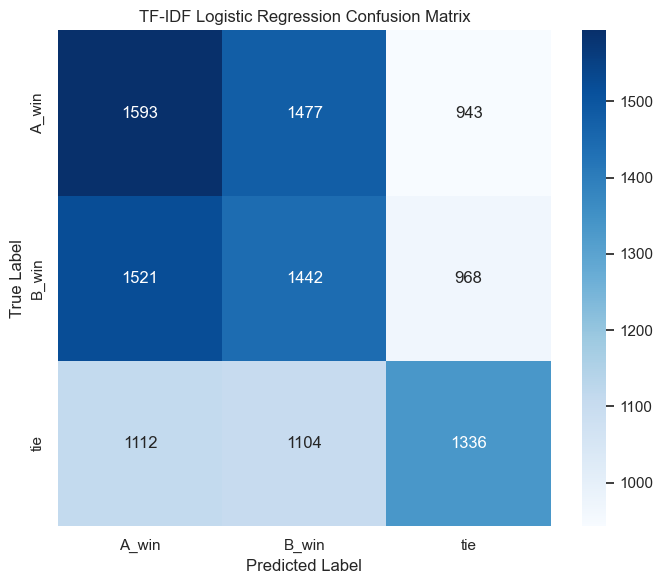

Saved figure: D:\LLM_Classification_finetuning\outputs\figures\tfidf_lr_confusion_matrix.png


In [9]:
plt.figure(figsize=(7, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=TARGET_NAMES,
    yticklabels=TARGET_NAMES,
)
plt.title('TF-IDF Logistic Regression Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.tight_layout()

confusion_matrix_path = figures_dir / 'tfidf_lr_confusion_matrix.png'
plt.savefig(confusion_matrix_path, dpi=150)
plt.show()

print(f'Saved figure: {confusion_matrix_path}')

## 10. Save Validation Predictions and Error Cases

Save out-of-fold validation predictions and a sorted error-case file.

In [10]:
valid_predictions = valid_part.copy()
valid_predictions['pred_label'] = valid_pred
valid_predictions['pred_label_name'] = valid_predictions['pred_label'].map(LABEL_NAME_MAP)
valid_predictions['prob_A_win'] = valid_prob[:, 0]
valid_predictions['prob_B_win'] = valid_prob[:, 1]
valid_predictions['prob_tie'] = valid_prob[:, 2]
valid_predictions['true_label_prob'] = valid_prob[np.arange(len(valid_predictions)), y_valid.to_numpy()]

valid_prediction_columns = [
    'id',
    'label',
    'label_name',
    'pred_label',
    'pred_label_name',
    'prob_A_win',
    'prob_B_win',
    'prob_tie',
    'prompt_clean',
    'response_a_clean',
    'response_b_clean',
    'response_a_char_len',
    'response_b_char_len',
    'response_len_diff',
]

valid_predictions_path = oof_dir / 'tfidf_lr_valid_predictions.csv'
valid_predictions[valid_prediction_columns].to_csv(valid_predictions_path, index=False, encoding='utf-8-sig')

error_cases = valid_predictions[valid_predictions['label'] != valid_predictions['pred_label']].copy()
error_cases = error_cases.sort_values('true_label_prob', ascending=True)

error_case_columns = valid_prediction_columns + ['true_label_prob']
error_cases_path = oof_dir / 'tfidf_lr_error_cases.csv'
error_cases[error_case_columns].to_csv(error_cases_path, index=False, encoding='utf-8-sig')

print(f'Saved validation predictions: {valid_predictions_path}')
print(f'Saved error cases: {error_cases_path}')
print(f'Number of error cases: {len(error_cases)}')

Saved validation predictions: D:\LLM_Classification_finetuning\outputs\oof\tfidf_lr_valid_predictions.csv
Saved error cases: D:\LLM_Classification_finetuning\outputs\oof\tfidf_lr_error_cases.csv
Number of error cases: 7125


## 11. Predict Test and Save Submission

Predict class probabilities for the Kaggle test set and save a submission file.

In [11]:
X_test_tfidf = vectorizer.transform(test['text_input'])
test_prob_raw = model.predict_proba(X_test_tfidf)
test_prob = align_probabilities(test_prob_raw, model.classes_, LABELS)

submission = pd.DataFrame({
    'id': test['id'],
    'winner_model_a': test_prob[:, 0],
    'winner_model_b': test_prob[:, 1],
    'winner_tie': test_prob[:, 2],
})

submission_path = submissions_dir / 'tfidf_lr_submission.csv'
submission.to_csv(submission_path, index=False, encoding='utf-8-sig')

print(f'Saved submission: {submission_path}')
display(submission.head())

Saved submission: D:\LLM_Classification_finetuning\outputs\submissions\tfidf_lr_submission.csv


,id,winner_model_a,winner_model_b,winner_tie
0,136060,0.187887,0.282840,0.529273
1,211333,0.534016,0.206395,0.259588
2,1233961,0.216874,0.699101,0.084024


## 12. Save Model Artifacts

Save the fitted vectorizer and logistic regression model with joblib.

In [12]:
vectorizer_path = models_dir / 'tfidf_vectorizer.joblib'
model_path = models_dir / 'tfidf_logistic_regression.joblib'

joblib.dump(vectorizer, vectorizer_path)
joblib.dump(model, model_path)

print(f'Saved vectorizer: {vectorizer_path}')
print(f'Saved model: {model_path}')

Saved vectorizer: D:\LLM_Classification_finetuning\outputs\models\tfidf_vectorizer.joblib
Saved model: D:\LLM_Classification_finetuning\outputs\models\tfidf_logistic_regression.joblib


## 13. Save Experiment Result

Append validation metrics and key hyperparameters to `experiment_results.csv`.

In [13]:
experiment_result = pd.DataFrame([
    {
        'model_name': 'tfidf_logistic_regression',
        'valid_log_loss': valid_log_loss,
        'valid_accuracy': valid_accuracy,
        'valid_macro_f1': valid_macro_f1,
        'max_features': 100000,
        'ngram_range': '(1, 2)',
        'C': 2.0,
        'random_state': RANDOM_STATE,
        'notes': 'TF-IDF on prompt_clean, response_a_clean, and response_b_clean. No model names used.',
    }
])

experiment_results_path = logs_dir / 'experiment_results.csv'

if experiment_results_path.exists():
    previous_results = pd.read_csv(experiment_results_path)
    experiment_results = pd.concat([previous_results, experiment_result], ignore_index=True)
else:
    experiment_results = experiment_result

experiment_results.to_csv(experiment_results_path, index=False, encoding='utf-8-sig')

print(f'Saved experiment results: {experiment_results_path}')
display(experiment_results.tail())

Saved experiment results: D:\LLM_Classification_finetuning\outputs\logs\experiment_results.csv


,model_name,valid_log_loss,valid_accuracy,valid_macro_f1,max_features,ngram_range,C,random_state,notes
0,tfidf_logistic_regression,1.13932,0.380219,0.38076,100000,"(1, 2)",2.0,42,"TF-IDF on prompt_clean, response_a_clean, and response_b_clean. No model names used."
1,tfidf_logistic_regression,1.13932,0.380219,0.38076,100000,"(1, 2)",2.0,42,"TF-IDF on prompt_clean, response_a_clean, and response_b_clean. No model names used."


## 14. Finished

The TF-IDF baseline workflow is complete.

In [14]:
print('TF-IDF baseline finished successfully.')

TF-IDF baseline finished successfully.


In [15]:
from pathlib import Path
import pandas as pd
import numpy as np

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

paths = {
    "submission": ROOT / "outputs" / "submissions" / "tfidf_lr_submission.csv",
    "valid_predictions": ROOT / "outputs" / "oof" / "tfidf_lr_valid_predictions.csv",
    "error_cases": ROOT / "outputs" / "oof" / "tfidf_lr_error_cases.csv",
    "vectorizer": ROOT / "outputs" / "models" / "tfidf_vectorizer.joblib",
    "model": ROOT / "outputs" / "models" / "tfidf_logistic_regression.joblib",
    "confusion_matrix": ROOT / "outputs" / "figures" / "tfidf_lr_confusion_matrix.png",
    "experiment_results": ROOT / "outputs" / "logs" / "experiment_results.csv",
}

print("File existence check:")
for name, path in paths.items():
    print(f"{name}: {path.exists()} -> {path}")

sub = pd.read_csv(paths["submission"])
valid_pred = pd.read_csv(paths["valid_predictions"])
errors = pd.read_csv(paths["error_cases"])
results = pd.read_csv(paths["experiment_results"])

print("\nSubmission shape:", sub.shape)
print(sub.head())

print("\nSubmission columns:")
print(sub.columns.tolist())

required_sub_cols = ["id", "winner_model_a", "winner_model_b", "winner_tie"]
print("\nSubmission columns correct:", sub.columns.tolist() == required_sub_cols)

prob_sum = sub[["winner_model_a", "winner_model_b", "winner_tie"]].sum(axis=1)
print("\nSubmission probability sum:")
print(prob_sum.describe())
print("All probability sums close to 1:", np.allclose(prob_sum, 1.0, atol=1e-6))

print("\nNaN check in submission:")
print(sub.isna().sum())

print("\nValid prediction shape:", valid_pred.shape)
print(valid_pred.head(3))

print("\nValid prediction label counts:")
print(valid_pred["label_name"].value_counts())

print("\nPredicted label counts:")
print(valid_pred["pred_label_name"].value_counts())

print("\nError cases shape:", errors.shape)
print(errors[[
    "id",
    "label_name",
    "pred_label_name",
    "true_label_prob",
    "response_len_diff"
]].head(10))

print("\nExperiment results:")
display(results.tail())

File existence check:
submission: True -> d:\LLM_Classification_finetuning\outputs\submissions\tfidf_lr_submission.csv
valid_predictions: True -> d:\LLM_Classification_finetuning\outputs\oof\tfidf_lr_valid_predictions.csv
error_cases: True -> d:\LLM_Classification_finetuning\outputs\oof\tfidf_lr_error_cases.csv
vectorizer: True -> d:\LLM_Classification_finetuning\outputs\models\tfidf_vectorizer.joblib
model: True -> d:\LLM_Classification_finetuning\outputs\models\tfidf_logistic_regression.joblib
confusion_matrix: True -> d:\LLM_Classification_finetuning\outputs\figures\tfidf_lr_confusion_matrix.png
experiment_results: True -> d:\LLM_Classification_finetuning\outputs\logs\experiment_results.csv

Submission shape: (3, 4)
        id  winner_model_a  winner_model_b  winner_tie
0   136060        0.187887        0.282840    0.529273
1   211333        0.534016        0.206395    0.259588
2  1233961        0.216874        0.699101    0.084024

Submission columns:
['id', 'winner_model_a', 'winn

,model_name,valid_log_loss,valid_accuracy,valid_macro_f1,max_features,ngram_range,C,random_state,notes
0,tfidf_logistic_regression,1.13932,0.380219,0.38076,100000,"(1, 2)",2.0,42,"TF-IDF on prompt_clean, response_a_clean, and response_b_clean. No model names used."
1,tfidf_logistic_regression,1.13932,0.380219,0.38076,100000,"(1, 2)",2.0,42,"TF-IDF on prompt_clean, response_a_clean, and response_b_clean. No model names used."


## 11. Quick Tuning for TF-IDF Logistic Regression

Run a small grid search over TF-IDF size, n-gram range, and Logistic Regression regularization strength. The tuning reuses the existing train and validation split.

In [16]:
max_features_options = [30000, 50000, 100000]
ngram_range_options = [(1, 1), (1, 2)]
C_options = [0.05, 0.1, 0.3, 0.5, 1.0]

X_train_tune = X_train if 'X_train' in globals() else train_part['text_input']
y_train_tune = y_train if 'y_train' in globals() else train_part['label'].astype(int)
X_valid_tune = X_valid if 'X_valid' in globals() else valid_part['text_input']
y_valid_tune = y_valid if 'y_valid' in globals() else valid_part['label'].astype(int)

tuning_results = []

for max_features in max_features_options:
    for ngram_range in ngram_range_options:
        for C in C_options:
            print(
                f'Training params: max_features={max_features}, '
                f'ngram_range={ngram_range}, C={C}'
            )

            tune_vectorizer = TfidfVectorizer(
                max_features=max_features,
                ngram_range=ngram_range,
                min_df=2,
                max_df=0.95,
                sublinear_tf=True,
                strip_accents='unicode',
            )
            X_train_tfidf_tune = tune_vectorizer.fit_transform(X_train_tune)
            X_valid_tfidf_tune = tune_vectorizer.transform(X_valid_tune)

            tune_model = LogisticRegression(
                C=C,
                max_iter=1000,
                solver='saga',
                n_jobs=-1,
                random_state=RANDOM_STATE,
            )
            tune_model.fit(X_train_tfidf_tune, y_train_tune)

            valid_prob_raw_tune = tune_model.predict_proba(X_valid_tfidf_tune)
            valid_prob_tune = align_probabilities(valid_prob_raw_tune, tune_model.classes_, LABELS)
            valid_pred_tune = np.argmax(valid_prob_tune, axis=1)

            result = {
                'max_features': max_features,
                'ngram_range': ngram_range,
                'C': C,
                'valid_log_loss': log_loss(y_valid_tune, valid_prob_tune, labels=LABELS),
                'valid_accuracy': accuracy_score(y_valid_tune, valid_pred_tune),
                'valid_macro_f1': f1_score(y_valid_tune, valid_pred_tune, average='macro'),
            }
            tuning_results.append(result)

            print(
                f"valid_log_loss={result['valid_log_loss']:.6f}, "
                f"valid_accuracy={result['valid_accuracy']:.6f}, "
                f"valid_macro_f1={result['valid_macro_f1']:.6f}"
            )

tuning_results_df = pd.DataFrame(tuning_results)
tuning_results_df = tuning_results_df.sort_values('valid_log_loss', ascending=True).reset_index(drop=True)

tuning_results_path = logs_dir / 'tfidf_lr_tuning_results.csv'
tuning_results_df.to_csv(tuning_results_path, index=False, encoding='utf-8-sig')

print(f'Saved tuning results: {tuning_results_path}')
display(tuning_results_df)

best_row = tuning_results_df.iloc[0]
best_params = {
    'max_features': int(best_row['max_features']),
    'ngram_range': best_row['ngram_range'],
    'C': float(best_row['C']),
}

print('Best params:')
print(best_params)
print(
    f"Best valid_log_loss={best_row['valid_log_loss']:.6f}, "
    f"valid_accuracy={best_row['valid_accuracy']:.6f}, "
    f"valid_macro_f1={best_row['valid_macro_f1']:.6f}"
)

best_vectorizer = TfidfVectorizer(
    max_features=best_params['max_features'],
    ngram_range=best_params['ngram_range'],
    min_df=2,
    max_df=0.95,
    sublinear_tf=True,
    strip_accents='unicode',
)

X_full_tfidf_best = best_vectorizer.fit_transform(train['text_input'])
y_full_best = train['label'].astype(int)

best_model = LogisticRegression(
    C=best_params['C'],
    max_iter=1000,
    solver='saga',
    n_jobs=-1,
    random_state=RANDOM_STATE,
)
best_model.fit(X_full_tfidf_best, y_full_best)

best_vectorizer_path = models_dir / 'tfidf_vectorizer_best.joblib'
best_model_path = models_dir / 'tfidf_logistic_regression_best.joblib'
joblib.dump(best_vectorizer, best_vectorizer_path)
joblib.dump(best_model, best_model_path)

X_test_tfidf_best = best_vectorizer.transform(test['text_input'])
test_prob_raw_best = best_model.predict_proba(X_test_tfidf_best)
test_prob_best = align_probabilities(test_prob_raw_best, best_model.classes_, LABELS)

best_submission = pd.DataFrame({
    'id': test['id'],
    'winner_model_a': test_prob_best[:, 0],
    'winner_model_b': test_prob_best[:, 1],
    'winner_tie': test_prob_best[:, 2],
})

best_submission_path = submissions_dir / 'tfidf_lr_best_submission.csv'
best_submission.to_csv(best_submission_path, index=False, encoding='utf-8-sig')

tuned_experiment_result = pd.DataFrame([
    {
        'model_name': 'tfidf_logistic_regression_tuned',
        'valid_log_loss': best_row['valid_log_loss'],
        'valid_accuracy': best_row['valid_accuracy'],
        'valid_macro_f1': best_row['valid_macro_f1'],
        'max_features': best_params['max_features'],
        'ngram_range': str(best_params['ngram_range']),
        'C': best_params['C'],
        'random_state': RANDOM_STATE,
        'notes': 'tuned C, max_features and ngram_range',
    }
])

experiment_results_path = logs_dir / 'experiment_results.csv'
if experiment_results_path.exists():
    experiment_results_existing = pd.read_csv(experiment_results_path, encoding='utf-8-sig')
    experiment_results_updated = pd.concat(
        [experiment_results_existing, tuned_experiment_result],
        ignore_index=True,
    )
else:
    experiment_results_updated = tuned_experiment_result

experiment_results_updated.to_csv(experiment_results_path, index=False, encoding='utf-8-sig')

print(f'Saved best vectorizer: {best_vectorizer_path}')
print(f'Saved best model: {best_model_path}')
print(f'Saved best submission: {best_submission_path}')
print(f'Updated experiment results: {experiment_results_path}')
print('TF-IDF quick tuning finished successfully.')

Training params: max_features=30000, ngram_range=(1, 1), C=0.05
valid_log_loss=1.083100, valid_accuracy=0.385699, valid_macro_f1=0.383022
Training params: max_features=30000, ngram_range=(1, 1), C=0.1
valid_log_loss=1.082495, valid_accuracy=0.386917, valid_macro_f1=0.386125
Training params: max_features=30000, ngram_range=(1, 1), C=0.3
valid_log_loss=1.088718, valid_accuracy=0.383960, valid_macro_f1=0.384263
Training params: max_features=30000, ngram_range=(1, 1), C=0.5
valid_log_loss=1.097440, valid_accuracy=0.381698, valid_macro_f1=0.382320
Training params: max_features=30000, ngram_range=(1, 1), C=1.0
valid_log_loss=1.119598, valid_accuracy=0.378566, valid_macro_f1=0.379157
Training params: max_features=30000, ngram_range=(1, 2), C=0.05
valid_log_loss=1.082398, valid_accuracy=0.385090, valid_macro_f1=0.381421
Training params: max_features=30000, ngram_range=(1, 2), C=0.1
valid_log_loss=1.081413, valid_accuracy=0.383873, valid_macro_f1=0.382800
Training params: max_features=30000, ng

,max_features,ngram_range,C,valid_log_loss,valid_accuracy,valid_macro_f1
0,100000,"(1, 2)",0.10,1.080877,0.385264,0.383576
1,50000,"(1, 2)",0.10,1.080992,0.386743,0.385398
2,30000,"(1, 2)",0.10,1.081413,0.383873,0.382800
3,100000,"(1, 1)",0.10,1.082040,0.388222,0.387130
4,50000,"(1, 1)",0.10,1.082224,0.387961,0.386762
5,30000,"(1, 2)",0.05,1.082398,0.385090,0.381421
6,50000,"(1, 2)",0.05,1.082474,0.384047,0.379789
7,30000,"(1, 1)",0.10,1.082495,0.386917,0.386125
8,100000,"(1, 2)",0.30,1.082724,0.387700,0.387914
9,100000,"(1, 2)",0.05,1.082830,0.384916,0.379370


Best params:
{'max_features': 100000, 'ngram_range': (1, 2), 'C': 0.1}
Best valid_log_loss=1.080877, valid_accuracy=0.385264, valid_macro_f1=0.383576
Saved best vectorizer: D:\LLM_Classification_finetuning\outputs\models\tfidf_vectorizer_best.joblib
Saved best model: D:\LLM_Classification_finetuning\outputs\models\tfidf_logistic_regression_best.joblib
Saved best submission: D:\LLM_Classification_finetuning\outputs\submissions\tfidf_lr_best_submission.csv
Updated experiment results: D:\LLM_Classification_finetuning\outputs\logs\experiment_results.csv
TF-IDF quick tuning finished successfully.


In [17]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

check_paths = [
    ROOT / "outputs" / "models" / "tfidf_vectorizer_best.joblib",
    ROOT / "outputs" / "models" / "tfidf_logistic_regression_best.joblib",
    ROOT / "outputs" / "submissions" / "tfidf_lr_best_submission.csv",
    ROOT / "outputs" / "logs" / "tfidf_lr_tuning_results.csv",
    ROOT / "outputs" / "logs" / "experiment_results.csv",
]

for path in check_paths:
    print(path.exists(), path)

tuning = pd.read_csv(ROOT / "outputs" / "logs" / "tfidf_lr_tuning_results.csv", encoding="utf-8-sig")
results = pd.read_csv(ROOT / "outputs" / "logs" / "experiment_results.csv", encoding="utf-8-sig")

print("\nTop tuning results:")
display(tuning.sort_values("valid_log_loss").head(10))

print("\nExperiment results:")
display(results.tail())

True d:\LLM_Classification_finetuning\outputs\models\tfidf_vectorizer_best.joblib
True d:\LLM_Classification_finetuning\outputs\models\tfidf_logistic_regression_best.joblib
True d:\LLM_Classification_finetuning\outputs\submissions\tfidf_lr_best_submission.csv
True d:\LLM_Classification_finetuning\outputs\logs\tfidf_lr_tuning_results.csv
True d:\LLM_Classification_finetuning\outputs\logs\experiment_results.csv

Top tuning results:


,max_features,ngram_range,C,valid_log_loss,valid_accuracy,valid_macro_f1
0,100000,"(1, 2)",0.10,1.080877,0.385264,0.383576
1,50000,"(1, 2)",0.10,1.080992,0.386743,0.385398
2,30000,"(1, 2)",0.10,1.081413,0.383873,0.382800
3,100000,"(1, 1)",0.10,1.082040,0.388222,0.387130
4,50000,"(1, 1)",0.10,1.082224,0.387961,0.386762
5,30000,"(1, 2)",0.05,1.082398,0.385090,0.381421
6,50000,"(1, 2)",0.05,1.082474,0.384047,0.379789
7,30000,"(1, 1)",0.10,1.082495,0.386917,0.386125
8,100000,"(1, 2)",0.30,1.082724,0.387700,0.387914
9,100000,"(1, 2)",0.05,1.082830,0.384916,0.379370



Experiment results:


,model_name,valid_log_loss,valid_accuracy,valid_macro_f1,max_features,ngram_range,C,random_state,notes
0,tfidf_logistic_regression,1.139320,0.380219,0.380760,100000,"(1, 2)",2.0,42,"TF-IDF on prompt_clean, response_a_clean, and response_b_clean. No model names used."
1,tfidf_logistic_regression,1.139320,0.380219,0.380760,100000,"(1, 2)",2.0,42,"TF-IDF on prompt_clean, response_a_clean, and response_b_clean. No model names used."
2,tfidf_logistic_regression_tuned,1.080877,0.385264,0.383576,100000,"(1, 2)",0.1,42,"tuned C, max_features and ngram_range"


In [ ]:
from pathlib import Path
import pandas as pd

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent

results = pd.read_csv(ROOT / "outputs" / "logs" / "experiment_results.csv", encoding="utf-8-sig")

cols = ["model_name", "valid_log_loss", "valid_accuracy", "valid_macro_f1", "notes"]
display(results[cols].tail(10))